Step 1 — Create the notebook

Step 2 — Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

pd.set_option("display.max_columns", None)

file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Step 3 — Check structure and data quality

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [4]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)

print("\nBlank TotalCharges:")
print((df["TotalCharges"].astype(str).str.strip() == "").sum())

TotalCharges dtype: str

Blank TotalCharges:
11


Step 4 — Check the target

In [5]:
print("Churn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [6]:
# Check TotalCharges before conversion

print("Data type:", df["TotalCharges"].dtype)

blank_total_charges = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Blank TotalCharges:", blank_total_charges)

Data type: str
Blank TotalCharges: 11


In [7]:
# Convert TotalCharges to numeric
# Invalid/blank values become NaN

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

TotalCharges dtype: float64
Missing TotalCharges: 11


Step 5 — Inspect the missing TotalCharges

In [8]:
missing_total = df[df["TotalCharges"].isna()]

print("Rows with missing TotalCharges:", len(missing_total))

missing_total[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn"
    ]
]

Rows with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


In [9]:
print(missing_total[["tenure", "MonthlyCharges", "Churn"]].describe())

       tenure  MonthlyCharges
count    11.0       11.000000
mean      0.0       41.418182
std       0.0       23.831484
min       0.0       19.700000
25%       0.0       20.125000
50%       0.0       25.750000
75%       0.0       58.975000
max       0.0       80.850000


Step 6 — Fix TotalCharges

In [10]:
# Replace missing TotalCharges for zero-tenure customers with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:",
      df["TotalCharges"].isna().sum())

print(
    "Zero-tenure customers:",
    (df["tenure"] == 0).sum()
)

Missing TotalCharges after cleaning: 0
Zero-tenure customers: 11


Step 7 — Check duplicates

In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


Step 8 — Check numerical variables

In [12]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


Step 9 — Churn rate by categorical features

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

# Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Dataset shape:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Dataset shape: (7043, 21)
Missing TotalCharges: 0


In [3]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_features:
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{'=' * 50}")
    print(f"{col}")
    print(churn_rate.round(2))


gender
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64

Partner
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    26.71
No     24.93
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

Contract
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

PaperlessBilling
PaperlessBilling
Yes    33.57
No     16.33
Name: Churn, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


Step 10 — Churn by tenure

In [4]:
tenure_bins = [0, 6, 12, 24, 36, 48, 60, 72]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ],
    include_lowest=True
)

tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn.round(2))

TenureGroup
0-6 months      52.94
7-12 months     35.89
13-24 months    28.71
25-36 months    21.63
37-48 months    19.03
49-60 months    14.42
61-72 months     6.61
Name: Churn, dtype: float64


In [5]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numeric_features:
    print(f"\n{'=' * 50}")
    print(col)

    summary = (
        df.groupby("Churn")[col]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
    )

    print(summary)


tenure
       count   mean  median    std  min  max
Churn                                       
No      5174  37.57    38.0  24.11    0   72
Yes     1869  17.98    10.0  19.53    1   72

MonthlyCharges
       count   mean  median    std    min     max
Churn                                            
No      5174  61.27   64.43  31.09  18.25  118.75
Yes     1869  74.44   79.65  24.67  18.85  118.35

TotalCharges
       count     mean   median      std    min      max
Churn                                                  
No      5174  2549.91  1679.52  2329.95   0.00  8672.45
Yes     1869  1531.80   703.55  1890.82  18.85  8684.80


<Figure size 800x500 with 0 Axes>

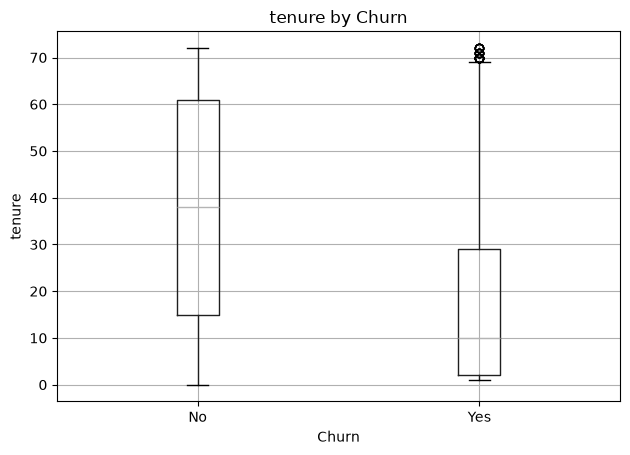

<Figure size 800x500 with 0 Axes>

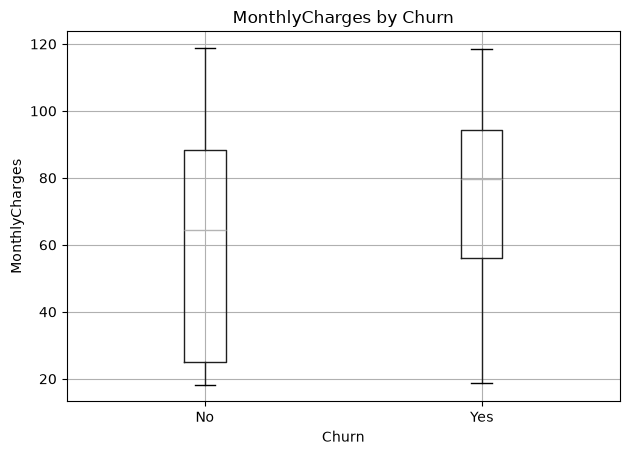

<Figure size 800x500 with 0 Axes>

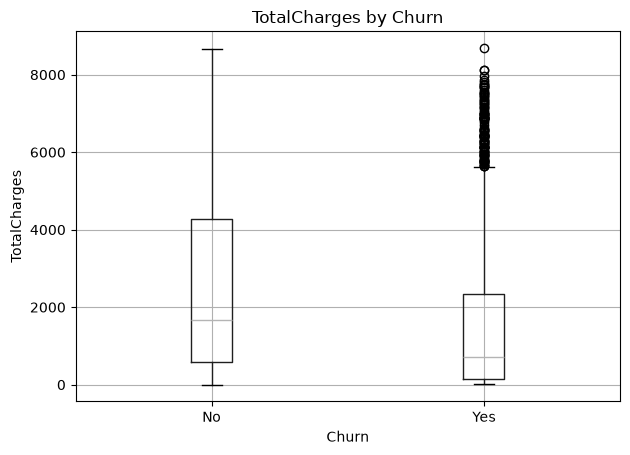

In [6]:
for col in numeric_features:
    plt.figure(figsize=(8, 5))

    df.boxplot(
        column=col,
        by="Churn"
    )

    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [7]:
#strongest categorical churn patterns
important_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaymentMethod"
]

for col in important_features:
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    print(churn_rate.round(2))


Contract
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Churn, dtype: float64

TechSupport
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Chur

In [8]:
output_path = "../data/processed/telco_churn_clean.csv"

df.to_csv(
    output_path,
    index=False
)

print("Cleaned Telco dataset saved successfully.")
print("Path:", output_path)
print("Shape:", df.shape)

Cleaned Telco dataset saved successfully.
Path: ../data/processed/telco_churn_clean.csv
Shape: (7043, 22)


In [9]:
#a compact EDA summary
print("===== TELCO CHURN EDA SUMMARY =====")

print("\nDataset shape:")
print(df.shape)

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(
    (df["Churn"].value_counts(normalize=True) * 100).round(2)
)

print("\nAverage numerical features by churn:")
print(
    df.groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean().round(2)
)

print("\nMedian numerical features by churn:")
print(
    df.groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].median().round(2)
)

===== TELCO CHURN EDA SUMMARY =====

Dataset shape:
(7043, 22)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Average numerical features by churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80

Median numerical features by churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55
